# Learning the velocity field around a NACA profile via a neural network

In [92]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

NACA airfoils were developed by the **National Advisory Committee for Aeronautics (NACA)** to systematically describe airfoil shapes used in aircraft design. The **4-digit NACA series** defines the airfoil geometry using four digits, such as in **NACA 2412**:

- **2** → Maximum camber is $2$% of the chord.
- **4** → Maximum camber is located at $40$% of the chord.
- **12** → Maximum thickness is $12$% of the chord.

Thus, **NACA 2412** has:
- Maximum camber $m = 0.02$
- Maximum camber position $p = 0.4$
- Maximum thickness $t = 0.12$
- Chord length $c = 1.0$ (by default)

The airfoil surface is defined by combining two components:

1. **Mean Camber Line (MCL)** — the curve halfway between the upper and lower surfaces.
2. **Thickness Distribution** — describes how thick the airfoil is at each position along the chord.

The total airfoil coordinates are derived by adding and subtracting the thickness distribution from the mean camber line. The thickness distribution $y_t$ is defined empirically as:

$$
y_t = 5t \left[ 0.2969\sqrt{\frac{x}{c}} - 0.1260\frac{x}{c} - 0.3516\left(\frac{x}{c}\right)^2 + 0.2843\left(\frac{x}{c}\right)^3 - 0.1015\left(\frac{x}{c}\right)^4 \right]
$$

where:
- $t$ is the maximum thickness as a fraction of the chord.
- $x$ varies from 0 (leading edge) to $c$ (trailing edge).

This equation gives the half-thickness distribution about the mean line. The mean camber line $y_c$ is defined differently before and after the maximum camber point:

$$
y_c =
\begin{cases}
\dfrac{m}{p^2} \left[ 2p \dfrac{x}{c} - \left(\dfrac{x}{c}\right)^2 \right], & 0 \leq x < p c \\
\dfrac{m}{(1-p)^2} \left[ (1 - 2p) + 2p \dfrac{x}{c} - \left(\dfrac{x}{c}\right)^2 \right], & p c \leq x \leq c
\end{cases}
$$

The derivative of $y_c$ with respect to $x$ is needed to find the camber line’s slope:

$$
\frac{dy_c}{dx} =
\begin{cases}
\dfrac{2m}{p^2}\left[p - \dfrac{x}{c}\right], & 0 \leq x < p c \\
\dfrac{2m}{(1-p)^2}\left[p - \dfrac{x}{c}\right], & p c \leq x \leq c
\end{cases}
$$

The angle $\theta$ of the camber line at each point is:

$$
\theta = \tan^{-1}\left(\frac{dy_c}{dx}\right)
$$

The coordinates of the **upper (u)** and **lower (l)** surfaces are obtained by offsetting the mean camber line by the thickness in the normal direction:

$$
\begin{aligned}
x_u &= x - y_t \sin(\theta) \\
y_u &= y_c + y_t \cos(\theta) \\
x_l &= x + y_t \sin(\theta) \\
y_l &= y_c - y_t \cos(\theta)
\end{aligned}
$$

These formulas yield the full shape of the airfoil. For **NACA 2412**, the parameters are:

$$
m = 0.02, \quad p = 0.4, \quad t = 0.12
$$

The code generates the airfoil by:
1. Creating an array of $x$ positions along the chord.
2. Computing $y_t$, $y_c$, and $\theta$.
3. Calculating $(x_u, y_u)$ and $(x_l, y_l)$.
4. Plotting both upper and lower surfaces to visualize the airfoil.

In [3]:
def naca4(m, p, t, c=1.0, n=200):
    """
    Generates the coordinates of a 4-digit NACA profile.
    m: maximum camber (e.g., 0.02 for NACA 2412)
    p: maximum camber position (e.g., 0.4)
    t: maximum thickness (e.g., 0.12)
    c: chord (1.0 by default)
    n: number of points
    """
    x = np.linspace(0, c, n)
    yt = 5*t*(0.2969*np.sqrt(x/c) - 0.1260*(x/c) - 0.3516*(x/c)**2 + 
              0.2843*(x/c)**3 - 0.1015*(x/c)**4)
    
    yc = np.where(x < p*c,
                  m/p**2*(2*p*(x/c)-(x/c)**2),
                  m/(1-p)**2*((1-2*p)+2*p*(x/c)-(x/c)**2))
    
    dyc_dx = np.where(x < p*c,
                      2*m/p**2*(p - x/c),
                      2*m/(1-p)**2*(p - x/c))
    theta = np.arctan(dyc_dx)
    
    xu = x - yt*np.sin(theta)
    yu = yc + yt*np.cos(theta)
    xl = x + yt*np.sin(theta)
    yl = yc - yt*np.cos(theta)
    
    return xu, yu, xl, yl

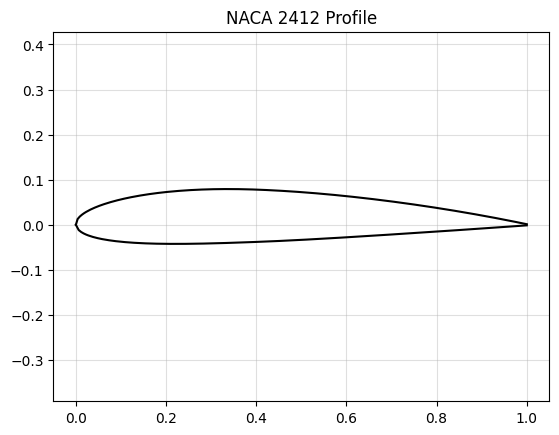

In [101]:
# Exemple : NACA 2412
xu, yu, xl, yl = naca4(0.02, 0.4, 0.12)
plt.plot(xu, yu, 'k', xl, yl, 'k')
plt.axis('equal')
plt.title("NACA 2412 Profile")
plt.grid(alpha=0.4)
plt.show()

After generating the geometry of the NACA airfoil, the next step is to model the flow field around it. This section creates an approximate velocity field using a simplified potential flow approach. The objective is to visualize how the air moves around the airfoil and how lift-like effects can be represented qualitatively.

We assume a uniform free-stream velocity disturbed by the presence of the airfoil. The base flow has a constant velocity $U_{\infty}$ and an incidence angle $\alpha$, representing the angle of attack between the free-stream direction and the airfoil chord line.

The flow domain is defined as a rectangular region in the $(x, y)$ plane, discretized with a regular mesh:
$$
(x_v, y_v) = \text{meshgrid}(x, y)
$$
Each grid point will have an associated velocity vector $(v_x, v_y)$.

To represent lift, a simple vortex-type perturbation is added to the uniform flow. The vortex introduces a circulation of intensity $\Gamma$, which generates asymmetric flow and simulates the lifting effect predicted by the Kutta–Joukowski theorem. The total velocity components are modeled as:

$$
\begin{align*}
v_x &= U_{\infty}\cos(\alpha) - \frac{\Gamma \, y_v}{r^2 + \varepsilon} \\
v_y &= U_{\infty}\sin(\alpha) + \frac{\Gamma \, (x_v - x_c)}{r^2 + \varepsilon} \\
r^2 &= (x_v - x_c)^2 + y_v^2
\end{align*}
$$

and $x_c$ is the approximate position of the vortex center (chosen near the quarter-chord). The small constant $\varepsilon$ prevents division by zero near the vortex core. The first term in each equation represents the undisturbed uniform flow, while the second term represents the rotational perturbation caused by the vortex. The resulting velocity field approximates the flow deflection around a cambered profile at a small angle of attack. To avoid visualizing the interior of the airfoil, points located within the geometry are masked. This is achieved by comparing the vertical position $y_v$ with the interpolated coordinates of the upper and lower surfaces $(x_u, y_u)$ and $(x_l, y_l)$:

$$
y_l(x) < y_v < y_u(x)
$$

Points satisfying this condition correspond to the solid region of the airfoil and are excluded from the flow visualization. Finally, the streamlines of the velocity field are plotted using:

$$
\text{plt.streamplot}(x_v, y_v, v_x, v_y)
$$

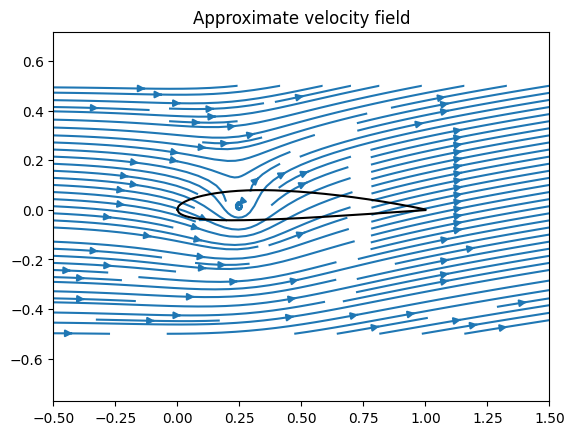

In [102]:
# To keep it simple, we model a flow potential field:
# Uniform field perturbed by the presence of the profile (rough approximation)

U_inf = 1.0  # uniform speed (m/s)
alpha = 5*np.pi/180  # angle of incidence (radians)

# Domain
xv, yv = np.meshgrid(np.linspace(-0.5, 1.5, 200),
                     np.linspace(-0.5, 0.5, 200))

# Approximation: uniform field + vortex type disturbance
gamma = 0.1  # vortex intensity to simulate lift
r2 = (xv - 0.25)**2 + yv**2
v_x = U_inf*np.cos(alpha) - gamma*yv/(r2+1e-3)
v_y = U_inf*np.sin(alpha) + gamma*(xv - 0.25)/(r2+1e-3)

# Profile masking (internal points excluded)
mask = (yv > np.interp(xv, xu, yu, left=0, right=0)) & \
       (yv < np.interp(xv, xl, yl, left=0, right=0))
v_x[mask] = np.nan
v_y[mask] = np.nan

plt.streamplot(xv, yv, v_x, v_y, density=1.2)
plt.plot(xu, yu, 'k', xl, yl, 'k')
plt.title("Approximate velocity field")
plt.axis('equal')
plt.show()

After computing the velocity field, we prepare the data for training a neural network model. Only valid points outside the airfoil are kept, removing NaN values corresponding to the masked interior. The remaining coordinates $(x, y)$ are stored in **X_data**, and the corresponding velocity components $(v_x, v_y)$ in **Y_data**.  

Both datasets are then converted into **PyTorch tensors**, allowing GPU computation and gradient-based learning. Finally, a **TensorDataset** and **DataLoader** are created to efficiently feed the model during training, using mini-batches of 1024 samples randomly shuffled at each epoch. 

In [105]:
# We only keep valid points (outside the profile)
valid = ~np.isnan(v_x)
X_data = np.vstack([xv[valid], yv[valid]]).T
Y_data = np.vstack([v_x[valid], v_y[valid]]).T

# Converting to PyTorch tensors
X_tensor = torch.tensor(X_data, dtype=torch.float32)
Y_tensor = torch.tensor(Y_data, dtype=torch.float32)

dataset = TensorDataset(X_tensor, Y_tensor)
train_loader = DataLoader(dataset, batch_size=1024, shuffle=True)

We define the neural network used to approximate the velocity field $\vec{v}(x, y) = (v_x, v_y)$ around the airfoil. The goal is to train a model that learns the mapping between spatial coordinates and their corresponding velocity vectors, based on the flow data previously generated.

The class **VelocityNet** inherits from PyTorch’s `nn.Module` and implements a simple feedforward **Multilayer Perceptron (MLP)**.  
The input layer receives two features — the spatial coordinates $(x, y)$.  
The output layer predicts two quantities — the velocity components $(v_x, v_y)$.  

The architecture consists of:
- A first linear transformation from 2 to 64 neurons.  
- A **Tanh** activation function introducing non-linearity, allowing the model to capture smooth but nonlinear relationships in the flow.  
- A second hidden layer (64 → 64) with another **Tanh** activation.  
- A final linear layer (64 → 2) that outputs the predicted velocities.  

Mathematically, the model performs a sequence of affine and nonlinear operations:
$$
\boxed{\hat{\vec{v}}(x, y) = W_3 \tanh(W_2 \tanh(W_1 [x, y]^T + b_1) + b_2) + b_3}
$$
where $W_i$ and $b_i$ are the weight matrices and biases learned during training. 

The following architecture  $(x, y)$ $\longrightarrow$ [Dense $64$] $\longrightarrow$ $tanh$ $\longrightarrow$ [Dense $64$] $\longrightarrow$ $tanh$ $\longrightarrow$ [Dense $2$ = $(v_x, v_y)$] is illustrated using 16 neurons per hidden layer instead of 64, to keep the diagram readable : 

![Scheme of Velocity Network](velocitynet_diagram.png)

The chosen loss function is the **Mean Squared Error (MSE)**:
$$
\mathcal{L} = \frac{1}{N} \sum_i \left\| \vec{v}_i - \hat{\vec{v}}_i \right\|^2
$$
which measures the difference between the true and predicted velocity vectors at all training points. The optimization is performed with the **Adam** algorithm, a variant of stochastic gradient descent that adapts the learning rate for each parameter to accelerate convergence:
$$
\theta_{t+1} = \theta_t - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
$$
where $\hat{m}_t$ and $\hat{v}_t$ are bias-corrected estimates of the gradient’s first and second moments.

In [107]:
# Neural network to approximate v(x,y)
class VelocityNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.model(x)

model = VelocityNet()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

This block trains the neural network to approximate the velocity field.  
For each of the 500 epochs, the model predicts velocities for mini-batches from the training data.  
The **mean squared error (MSE)** between predicted and true velocities is computed as the loss.  
Gradients are calculated via backpropagation (`loss.backward()`) and weights are updated using the **Adam optimizer** (`optimizer.step()`). 

In [108]:
# Network training
epochs = 500
for epoch in range(epochs):
    for xb, yb in train_loader:
        pred = model(xb)
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d} | Loss = {loss.item():.4e}")

Epoch 000 | Loss = 2.3412e-02
Epoch 050 | Loss = 1.0573e-02
Epoch 100 | Loss = 3.9513e-03
Epoch 150 | Loss = 4.9589e-04
Epoch 200 | Loss = 2.7436e-04
Epoch 250 | Loss = 3.0145e-04
Epoch 300 | Loss = 1.2019e-04
Epoch 350 | Loss = 1.0966e-04
Epoch 400 | Loss = 1.2355e-04
Epoch 450 | Loss = 6.7195e-05


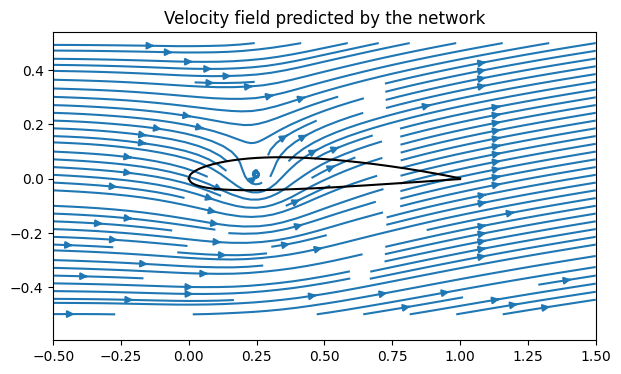

In [110]:
# Visualization of the prediction
with torch.no_grad():
    X_grid = torch.tensor(np.vstack([xv.ravel(), yv.ravel()]).T, dtype=torch.float32)
    V_pred = model(X_grid).numpy()

vxp = V_pred[:,0].reshape(xv.shape)
vyp = V_pred[:,1].reshape(yv.shape)

plt.figure(figsize=(7,4))
plt.streamplot(xv, yv, vxp, vyp, density=1.2)
plt.plot(xu, yu, 'k', xl, yl, 'k')
plt.axis('equal')
plt.title("Velocity field predicted by the network")
plt.show()

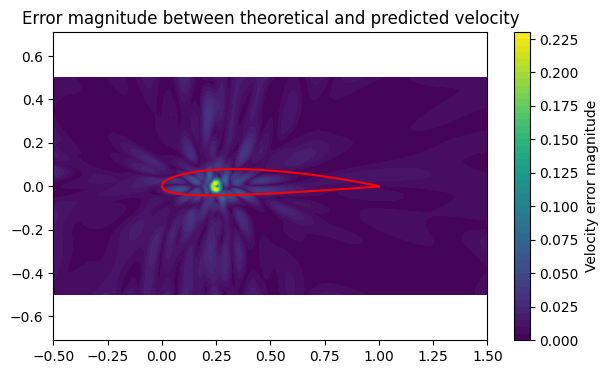

In [113]:
# Compute the difference between predicted and reference velocities
vxe_error = v_x - vxp
vye_error = v_y - vyp

# Compute magnitude of the error
error_magnitude = np.sqrt(vxe_error**2 + vye_error**2)

# Plot error magnitude as a heatmap
plt.figure(figsize=(7,4))
plt.contourf(xv, yv, error_magnitude, levels=50, cmap='viridis')
plt.colorbar(label='Velocity error magnitude')
plt.plot(xu, yu, 'r', xl, yl, 'r')  # airfoil contour
plt.axis('equal')
plt.title("Error magnitude between theoretical and predicted velocity")
plt.show()

In [111]:
# Comparison and error analysis
mask_valid = ~np.isnan(v_x)
mse_vx = np.mean((vxp[mask_valid] - v_x[mask_valid])**2)
mse_vy = np.mean((vyp[mask_valid] - v_y[mask_valid])**2)
print(f"Erreur quadratique moyenne : vx={mse_vx:.3e}, vy={mse_vy:.3e}")

Erreur quadratique moyenne : vx=8.393e-05, vy=5.859e-05


The mean squared errors indicate that the network predicts the velocity components with high accuracy.  
Specifically, the MSE for $v_x$ is $8.39 \times 10^{-5}$ and for $v_y$ is $5.86 \times 10^{-5}$,  
showing that the neural network has successfully learned the mapping from $(x, y)$ coordinates to velocity vectors around the airfoil.

In [12]:
%whos

Variable        Type             Data/Info
------------------------------------------
DataLoader      type             <class 'torch.utils.data.dataloader.DataLoader'>
TensorDataset   type             <class 'torch.utils.data.dataset.TensorDataset'>
U_inf           float            1.0
V_pred          ndarray          40000x2: 80000 elems, type `float32`, 320000 bytes (312.5 kb)
VelocityNet     type             <class '__main__.VelocityNet'>
X_data          ndarray          40000x2: 80000 elems, type `float64`, 640000 bytes (625.0 kb)
X_grid          Tensor           tensor([[-0.5000, -0.5000<...>     [ 1.5000,  0.5000]])
X_tensor        Tensor           tensor([[-0.5000, -0.5000<...>     [ 1.5000,  0.5000]])
Y_data          ndarray          40000x2: 80000 elems, type `float64`, 640000 bytes (625.0 kb)
Y_tensor        Tensor           tensor([[ 1.0577, -0.0050<...>     [ 0.9686,  0.1561]])
alpha           float            0.08726646259971647
dataset         TensorDataset    <torch.util